<a href="https://colab.research.google.com/github/MahdiMashayekhi-AI/Machine-Learning-Projects/blob/main/01-data-preprocessing/feature-selection/Feature_Selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature Selection

## Importing necessary libaraies

In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, make_scorer

## Reading data and EDA

In [4]:
df = pd.read_csv("/content/parkinsons.csv")

In [5]:
df.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [6]:
print("Number of rows: ", df.shape[0])
print("Number of columns: ", df.shape[1])

Number of rows:  195
Number of columns:  24


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

In [8]:
print("Number of null values: ", df.isnull().sum())

Number of null values:  name                0
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
status              0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
dtype: int64


In [9]:
df.columns

Index(['name', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)',
       'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP',
       'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
       'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA',
       'spread1', 'spread2', 'D2', 'PPE'],
      dtype='object')

In [10]:
print("Number of duplicate values: ", df.duplicated().sum())

Number of duplicate values:  0


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MDVP:Fo(Hz),195.0,154.228641,41.390065,88.333000,117.572000,148.790000,182.769000,260.105000
MDVP:Fhi(Hz),195.0,197.104918,91.491548,102.145000,134.862500,175.829000,224.205500,592.030000
MDVP:Flo(Hz),195.0,116.324631,43.521413,65.476000,84.291000,104.315000,140.018500,239.170000
MDVP:Jitter(%),195.0,0.006220,0.004848,0.001680,0.003460,0.004940,0.007365,0.033160
MDVP:Jitter(Abs),195.0,0.000044,0.000035,0.000007,0.000020,0.000030,0.000060,0.000260
MDVP:RAP,195.0,0.003306,0.002968,0.000680,0.001660,0.002500,0.003835,0.021440
MDVP:PPQ,195.0,0.003446,0.002759,0.000920,0.001860,0.002690,0.003955,0.019580
Jitter:DDP,195.0,0.009920,0.008903,0.002040,0.004985,0.007490,0.011505,0.064330
MDVP:Shimmer,195.0,0.029709,0.018857,0.009540,0.016505,0.022970,0.037885,0.119080
MDVP:Shimmer(dB),195.0,0.282251,0.194877,0.085000,0.148500,0.221000,0.350000,1.302000


## Separating data into X and y

In [12]:
X = df.drop(['name', 'status'], axis=1)
y = df['status']

In [13]:
print("Shape of X: ", X.shape)
print("Shape of y: ", y.shape)

Shape of X:  (195, 22)
Shape of y:  (195,)


## Data Preprocessing

In [14]:
# Perform robust scaler
scaler = RobustScaler()
X_robust_scaled = scaler.fit_transform(X)

### Method 1: Variance Threshold

In [15]:
thresholds = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
selected_features_counts = []

f1_scorer = make_scorer(f1_score)

f1_scores_list = []
median_f1_scores = []

for threshold in thresholds:
  # Apply variance threshold
  selector = VarianceThreshold(threshold)
  X_high_variance = selector.fit_transform(X_robust_scaled)
  selected_features_counts.append(X_high_variance.shape[1])

  # Fit logistic regression and collect F1 scores
  model = LogisticRegression()
  f1_scores = cross_val_score(model, X_high_variance, y, cv=10, scoring=f1_scorer)
  f1_scores_list.append(f1_scores)
  median_f1_scores.append(np.median(f1_scores))

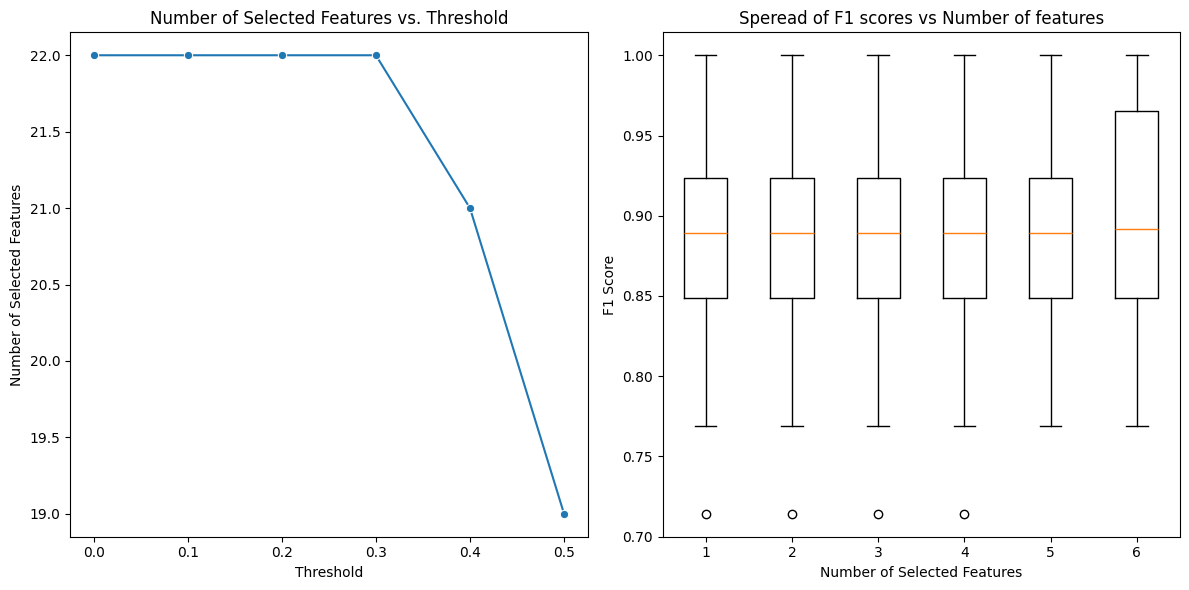

In [16]:
# Plot how many features are selected based on the threshold values
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.lineplot(x=thresholds, y=selected_features_counts, marker='o')
plt.title('Number of Selected Features vs. Threshold')
plt.xlabel('Threshold')
plt.ylabel('Number of Selected Features')

# Plot boxplot of F1 Scores against the numbers of selected features
plt.subplot(1, 2, 2)
plt.boxplot(f1_scores_list, label=selected_features_counts)
plt.title('Speread of F1 scores vs Number of features')
plt.xlabel('Number of Selected Features')
plt.ylabel('F1 Score')

plt.tight_layout()
plt.show()

In [17]:
# Dispaly the result in DataFrame
result_df = pd.DataFrame({'Thresholds' : thresholds, 'Feature count' : selected_features_counts, 'Median F1 Score' : median_f1_scores})
result_df

,Thresholds,Feature count,Median F1 Score
0,0.0,22,0.889113
1,0.1,22,0.889113
2,0.2,22,0.889113
3,0.3,22,0.889113
4,0.4,21,0.889113
5,0.5,19,0.892045


### Method 2: Select K-Best

In [18]:
from sklearn.feature_selection import SelectKBest, f_classif

df = pd.read_csv("/content/parkinsons.csv")

X = df.drop(['name', 'status'], axis=1)
y = df['status']

print("Shape of X: ", X.shape)
print("Shape of y: ", y.shape)

scaler = RobustScaler()
X_robust_scaled = scaler.fit_transform(X)

Shape of X:  (195, 22)
Shape of y:  (195,)


In [20]:
k_values = [5, 10, 15, 20, 22]
selected_features_counts_kbest = []

f1_scorer = make_scorer(f1_score)

f1_scores_kbest_list = []
median_f1_score_kbest = []

for k in k_values:
  selector = SelectKBest(f_classif, k=k)
  X_kbest = selector.fit_transform(X_robust_scaled, y)
  selected_features_counts_kbest.append(X_kbest.shape[1])

  model = LogisticRegression()
  f1_scores_kbest = cross_val_score(model, X_kbest, y, cv=10, scoring=f1_scorer)
  f1_scores_kbest_list.append(f1_scores_kbest)
  median_f1_score_kbest.append(np.median(f1_scores_kbest))

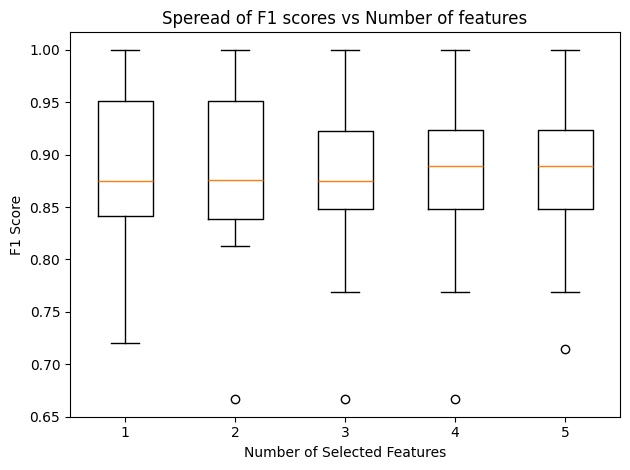

In [26]:
# Plot boxplot of F1 Scores against the numbers of selected features
plt.boxplot(f1_scores_kbest_list, label=selected_features_counts_kbest)
plt.title('Speread of F1 scores vs Number of features')
plt.xlabel('Number of Selected Features')
plt.ylabel('F1 Score')

plt.tight_layout()
plt.show()

In [24]:
# Display the result in a DataFrame
results_df_kbest = pd.DataFrame({'Feature Count': selected_features_counts_kbest, 'Median F1 Score': median_f1_score_kbest})
results_df_kbest.sort_values(by='Median F1 Score', ascending=False)

,Feature Count,Median F1 Score
4,22,0.889113
3,20,0.889113
1,10,0.875855
0,5,0.875000
2,15,0.875000


### Method 3: Recursive Feature Elimination

In [27]:
from sklearn.feature_selection import RFE

df = pd.read_csv("/content/parkinsons.csv")

X = df.drop(['name', 'status'], axis=1)
y = df['status']

print("Shape of X: ", X.shape)
print("Shape of y: ", y.shape)

scaler = RobustScaler()
X_robust_scaled = scaler.fit_transform(X)

Shape of X:  (195, 22)
Shape of y:  (195,)


In [28]:
n_features_values = [5, 10, 15, 20, 22]
selected_features_counts_ref = []

f1_scorer = make_scorer(f1_score)

f1_scores_ref_list = []
median_f1_score_ref = []

for n_features_to_select in n_features_values:
  selector = RFE(estimator=LogisticRegression(), n_features_to_select=n_features_to_select)
  X_ref = selector.fit_transform(X_robust_scaled, y)
  selected_features_counts_ref.append(X_ref.shape[1])

  model = LogisticRegression()
  f1_scores_ref = cross_val_score(model, X_ref, y, cv=10, scoring=f1_scorer)
  f1_scores_ref_list.append(f1_scores_ref)
  median_f1_score_ref.append(np.median(f1_scores_ref))

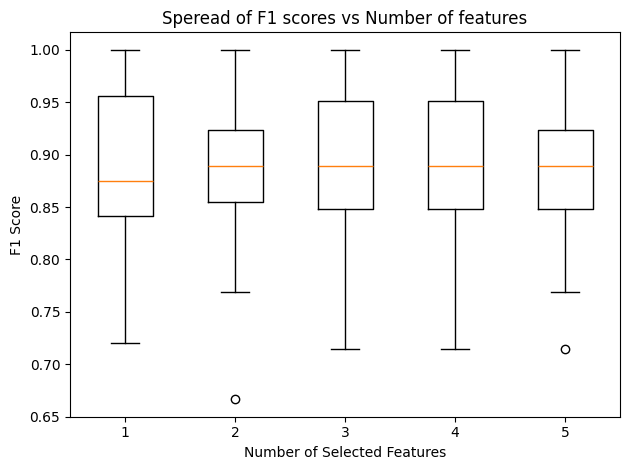

In [29]:
# Plot boxplot of F1 Scores against the numbers of selected features
plt.boxplot(f1_scores_ref_list, label=selected_features_counts_ref)
plt.title('Speread of F1 scores vs Number of features')
plt.xlabel('Number of Selected Features')
plt.ylabel('F1 Score')

plt.tight_layout()
plt.show()

In [30]:
results_df_ref = pd.DataFrame({'Feature Count': selected_features_counts_ref, 'Median F1 Score': median_f1_score_ref})
results_df_ref.sort_values(by='Median F1 Score', ascending=False)

,Feature Count,Median F1 Score
1,10,0.889113
3,20,0.889113
2,15,0.889113
4,22,0.889113
0,5,0.875000


### Method 4: Select From Model

In [31]:
from sklearn.feature_selection import SelectFromModel

df = pd.read_csv("/content/parkinsons.csv")

X = df.drop(['name', 'status'], axis=1)
y = df['status']

print("Shape of X: ", X.shape)
print("Shape of y: ", y.shape)

scaler = RobustScaler()
X_robust_scaled = scaler.fit_transform(X)

Shape of X:  (195, 22)
Shape of y:  (195,)


In [33]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]
selected_features_counts_sfm = []

f1_scorer = make_scorer(f1_score)

f1_scores_sfm_list = []
median_f1_score_sfm = []

for threshold in thresholds:
  selector = SelectFromModel(estimator=LogisticRegression(), threshold=threshold)
  X_sfm = selector.fit_transform(X_robust_scaled, y)
  selected_features_counts_sfm.append(X_sfm.shape[1])

  model = LogisticRegression()
  f1_scores_sfm = cross_val_score(model, X_sfm, y, cv=10, scoring=f1_scorer)
  f1_scores_sfm_list.append(f1_scores_sfm)
  median_f1_score_sfm.append(np.median(f1_scores_sfm))

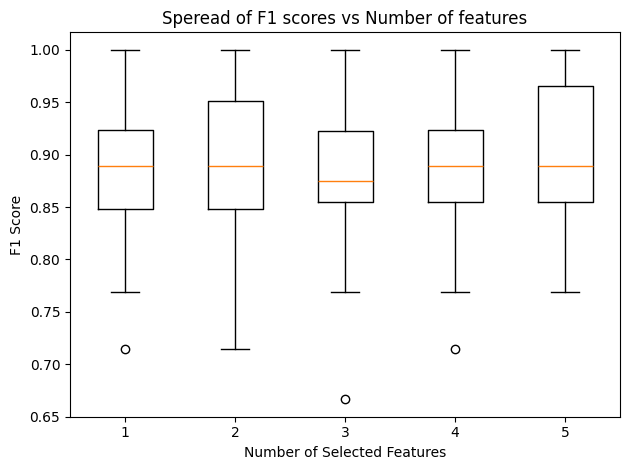

In [34]:
# Plot boxplot of F1 Scores against the numbers of selected features
plt.boxplot(f1_scores_sfm_list, label=selected_features_counts_sfm)
plt.title('Speread of F1 scores vs Number of features')
plt.xlabel('Number of Selected Features')
plt.ylabel('F1 Score')

plt.tight_layout()
plt.show()

In [35]:
results_df_sfm = pd.DataFrame({'Feature Count' : selected_features_counts_sfm, 'Median F1 Score' : median_f1_score_sfm})
results_df_sfm.sort_values(by='Median F1 Score', ascending=False)

,Feature Count,Median F1 Score
0,22,0.889113
1,18,0.889113
3,11,0.889113
4,8,0.889113
2,12,0.875000


### Method 5: Sequential Feature Selector

In [36]:
from sklearn.feature_selection import SequentialFeatureSelector

df = pd.read_csv("/content/parkinsons.csv")

X = df.drop(['name', 'status'], axis=1)
y = df['status']

print("Shape of X: ", X.shape)
print("Shape of y: ", y.shape)

scaler = RobustScaler()
X_robust_scaled = scaler.fit_transform(X)

Shape of X:  (195, 22)
Shape of y:  (195,)


In [37]:
n_features_values = [5, 10, 15, 20, 21]
selected_features_counts_sfs = []

f1_scorer = make_scorer(f1_score)

f1_scores_sfs_list = []
median_f1_score_sfs = []

for n_features in n_features_values:
  selector = SequentialFeatureSelector(estimator=LogisticRegression(), n_features_to_select=n_features)
  X_sfs = selector.fit_transform(X_robust_scaled, y)
  selected_features_counts_sfs.append(X_sfs.shape[1])

  model = LogisticRegression()
  f1_scores_sfs = cross_val_score(model, X_sfs, y, cv=10, scoring=f1_scorer)
  f1_scores_sfs_list.append(f1_scores_sfs)
  median_f1_score_sfs.append(np.median(f1_scores_sfs))

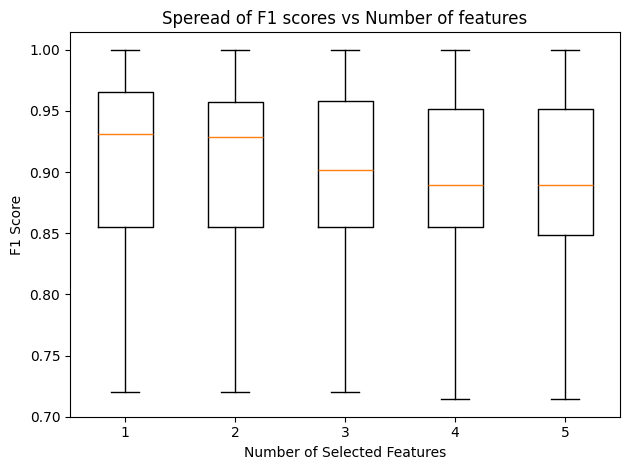

In [38]:
# Plot boxplot of F1 Scores against the numbers of selected features
plt.boxplot(f1_scores_sfs_list, label=selected_features_counts_sfs)
plt.title('Speread of F1 scores vs Number of features')
plt.xlabel('Number of Selected Features')
plt.ylabel('F1 Score')

plt.tight_layout()
plt.show()

In [39]:
results_df_sfs = pd.DataFrame({'Feature Count' : selected_features_counts_sfs, 'Median F1 Score' : median_f1_score_sfs})
results_df_sfs.sort_values(by='Median F1 Score', ascending=False)

,Feature Count,Median F1 Score
0,5,0.930952
1,10,0.928571
2,15,0.901786
3,20,0.889113
4,21,0.889113


In [41]:
sfs = SequentialFeatureSelector(model, n_features_to_select=5, direction='forward', cv=10)
sfs.fit(X_robust_scaled, y)

selected_feature_names = list(X.columns[sfs.get_support()])
print("Selected Features:", selected_feature_names)

Selected Features: ['MDVP:Jitter(%)', 'Shimmer:APQ5', 'DFA', 'D2', 'PPE']
